In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

In [2]:
timeline_path = 'result_230426_032731_769412/0_mondrian_0.0/test_cam_0/timeline_192.168.0.7:45869_1.csv'

In [3]:
df = pd.read_csv(timeline_path, delimiter='\t')
print(df.shape)
df = df[df['scheduleID'] != -1]
print(df.shape)
df = df[(df['fullInferenceStartTime'] != 0) | (df['mixedInferenceStartTime'] != 0)]
print(df.shape)
df.head()

(4922, 29)
(4921, 29)
(4919, 29)


,videoId,frameIndex,scheduleID,PDExtractorID,OFExtractorID,numBoxes,numROIs,numMergedROIs,inferenceFrameSize,inferenceDevice,...,mergeROIStartTime,mergeROIEndTime,mixingStartTime,mixingEndTime,scheduledTime,mixedInferenceStartTime,mixedInferenceEndTime,reconstructStartTime,reconstructEndTime,endTime
1,0,1,0,0,0,0,4,4,640,0,...,850892,850951,850991,851079,5885258,8239499,8399742,8400152,8403853,8419734
2,0,2,0,0,0,0,5,5,640,0,...,858522,858574,858606,858692,5885258,8239499,8399742,8400152,8403853,8419736
3,0,3,0,0,0,0,5,5,640,0,...,868925,868961,868987,869060,5885258,8239499,8399742,8400152,8403853,8419737
4,0,4,0,1,1,0,5,5,640,0,...,873133,873177,873206,873499,5885258,8239499,8399742,8400152,8403853,8419738
5,0,5,0,0,0,1,5,3,640,0,...,879198,879246,879270,879350,5885258,8239499,8399742,8400152,8403853,8419740


In [4]:
times = [
    'enqueueTime',
    'fullInferenceStartTime',
    'fullInferenceEndTime',
    'pixelDiffROIProcessStartTime',
    'pixelDiffROIProcessEndTime',
    'opticalFlowROIProcessStartTime',
    'opticalFlowROIProcessEndTime',
    'resizeStartTime',
    'resizeEndTime',
    'mergeROIStartTime',
    'mergeROIEndTime',
    'mixingStartTime',
    'mixingEndTime',
    'scheduledTime',
    'mixedInferenceStartTime',
    'mixedInferenceEndTime',
    'reconstructStartTime',
    'reconstructEndTime',
    'endTime',
]
for time in times:
    assert np.all(df[time].values >= 0)

In [5]:
df_full = df[df['fullInferenceStartTime'] != 0]
df_pack = df[df['fullInferenceStartTime'] == 0]

### Full Frame

In [6]:
print(df_full.shape)
print('Num Violations:', sum((df_full['endTime'] - df_full['enqueueTime']) > 5e6))
for time in times:
    print(f'{time:<30}', sum(df_full[time] == 0))

(14, 29)
Num Violations: 0
enqueueTime                    0
fullInferenceStartTime         0
fullInferenceEndTime           0
pixelDiffROIProcessStartTime   0
pixelDiffROIProcessEndTime     0
opticalFlowROIProcessStartTime 0
opticalFlowROIProcessEndTime   0
resizeStartTime                0
resizeEndTime                  0
mergeROIStartTime              0
mergeROIEndTime                0
mixingStartTime                0
mixingEndTime                  0
scheduledTime                  0
mixedInferenceStartTime        14
mixedInferenceEndTime          14
reconstructStartTime           14
reconstructEndTime             14
endTime                        0


### Packed Inference

In [7]:
print(df_pack.shape)
print('Num Violations:', sum((df_pack['endTime'] - df_pack['enqueueTime']) > 5e6))
for time in times:
    print(f'{time:<30}', sum(df_pack[time] == 0))

(4905, 29)
Num Violations: 1231
enqueueTime                    0
fullInferenceStartTime         4905
fullInferenceEndTime           4905
pixelDiffROIProcessStartTime   0
pixelDiffROIProcessEndTime     0
opticalFlowROIProcessStartTime 0
opticalFlowROIProcessEndTime   0
resizeStartTime                0
resizeEndTime                  0
mergeROIStartTime              0
mergeROIEndTime                0
mixingStartTime                0
mixingEndTime                  0
scheduledTime                  0
mixedInferenceStartTime        0
mixedInferenceEndTime          0
reconstructStartTime           0
reconstructEndTime             0
endTime                        0


#### Breakdown

In [8]:
times = [
    'enqueueTime',
    'pixelDiffROIProcessStartTime',
    'pixelDiffROIProcessEndTime',
    'opticalFlowROIProcessStartTime',
    'opticalFlowROIProcessEndTime',
    'resizeStartTime',
    'resizeEndTime',
    'mergeROIStartTime',
    'mergeROIEndTime',
    'mixingStartTime',
    'mixingEndTime',
    'scheduledTime',
    'mixedInferenceStartTime',
    'mixedInferenceEndTime',
    'reconstructStartTime',
    'reconstructEndTime',
    'endTime',
]
df_violated = df_pack[(df_pack['endTime'] - df_pack['enqueueTime']) > 5e6]
df_ok = df_pack[(df_pack['endTime'] - df_pack['enqueueTime']) <= 5e6]
print(np.mean(df_violated['endTime'] - df_violated['enqueueTime']) / 1e6)
print(f'{"Start":<30}    {"End":<30}   {"Violated":>8} {"OK":>8}')
for stime, etime in zip(times[:-1], times[1:]):
    print(f'{stime:<30} => {etime:<30} : {np.mean(df_violated[etime] - df_violated[stime])/1e3:>8.3f} {np.mean(df_ok[etime] - df_ok[stime])/1e3:>8.3f}')

6.540843232331438
Start                             End                              Violated       OK
enqueueTime                    => pixelDiffROIProcessStartTime   :    1.092    1.098
pixelDiffROIProcessStartTime   => pixelDiffROIProcessEndTime     :    1.822    1.763
pixelDiffROIProcessEndTime     => opticalFlowROIProcessStartTime : 1938.169  267.633
opticalFlowROIProcessStartTime => opticalFlowROIProcessEndTime   :    1.460    0.526
opticalFlowROIProcessEndTime   => resizeStartTime                :    0.045    0.029
resizeStartTime                => resizeEndTime                  :    0.018    0.008
resizeEndTime                  => mergeROIStartTime              :    0.000    0.000
mergeROIStartTime              => mergeROIEndTime                :    0.040    0.040
mergeROIEndTime                => mixingStartTime                :    0.018    0.014
mixingStartTime                => mixingEndTime                  :    0.075    0.079
mixingEndTime                  => scheduledTime

In [9]:
pdToOf = df_violated['opticalFlowROIProcessStartTime'] - df_violated['pixelDiffROIProcessEndTime']

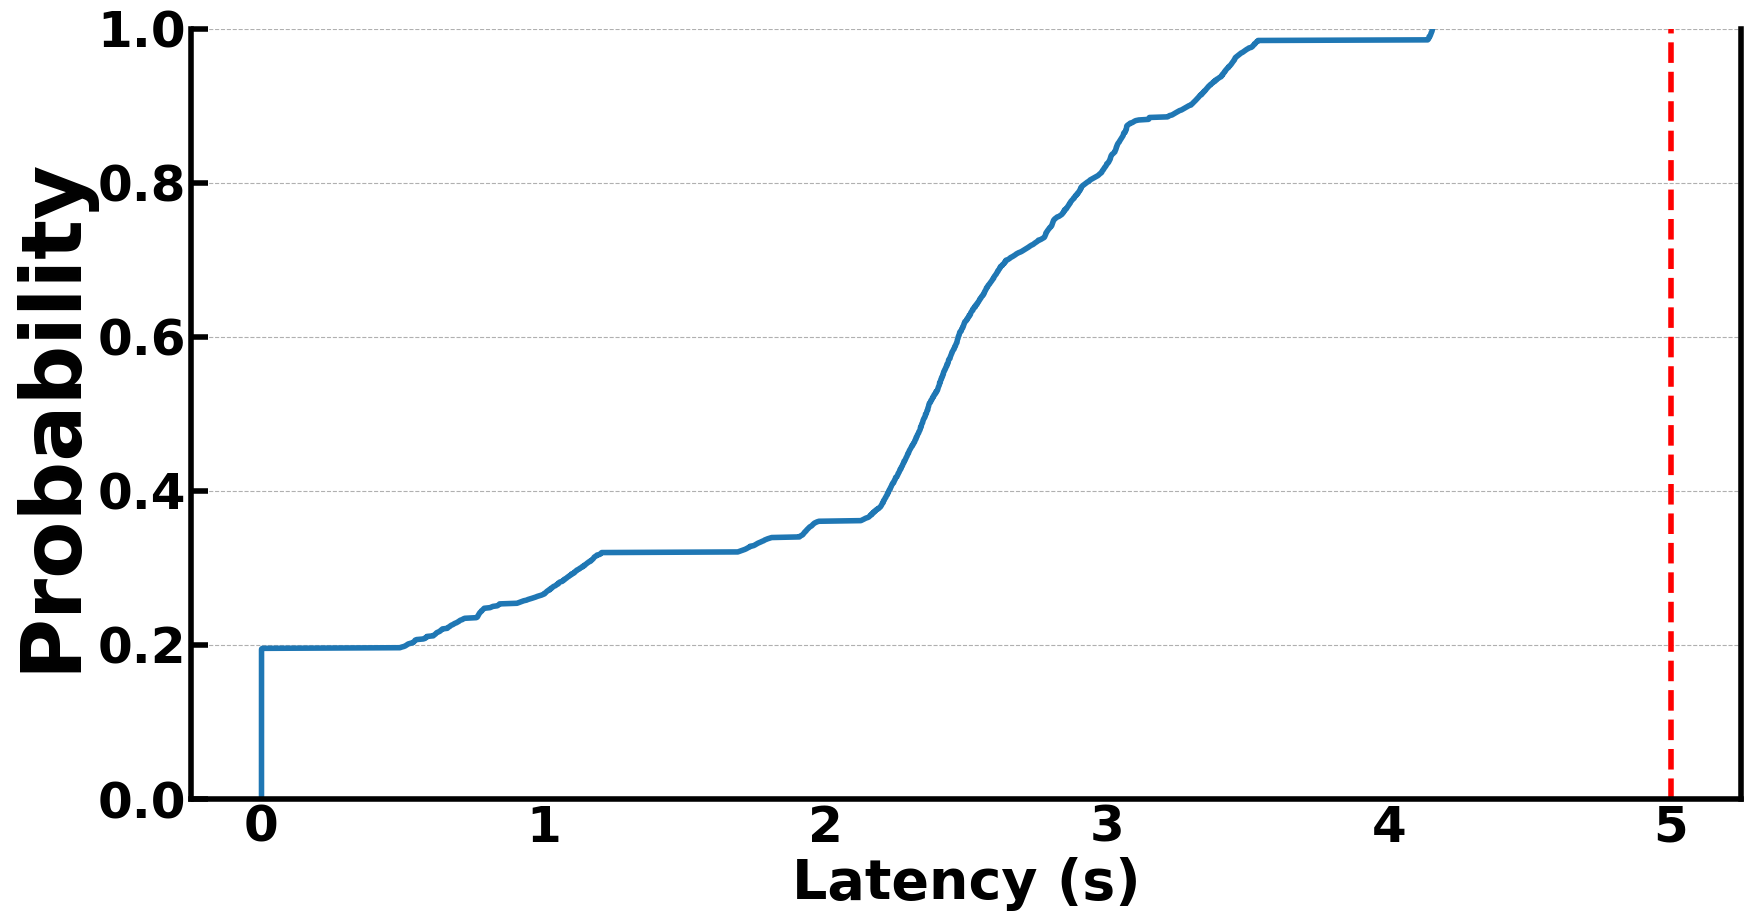

In [10]:
xlabelfontsize = 40
ylabelfontsize = 60
ticklabelfontsize = 36
legendfontsize = 26
lw = 4
markersize = 15


fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(np.sort(pdToOf) / 1e6, np.linspace(0, 1, len(pdToOf)), linewidth=lw)

ax.grid(axis='y', linestyle='--')
ax.set_axisbelow(True)

ax.axvline(x=5, c='r', linestyle='--', linewidth=lw)
ax.set_xlabel('Latency (s)', fontsize=xlabelfontsize, fontweight='bold')
ax.set_ylabel('Probability', fontsize=ylabelfontsize, fontweight='bold')
ax.set_ylim(0, 1)

ticklabels = ax.get_xticklabels() + ax.get_yticklabels()
[ticklabel.set_fontsize(ticklabelfontsize) for ticklabel in ticklabels]
[ticklabel.set_fontweight('bold') for ticklabel in ticklabels]

ax.spines['left'].set_linewidth(lw)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_linewidth(lw)
ax.spines['bottom'].set_linewidth(lw)

ax.tick_params('x', which='minor', direction='in', length=12, width=lw)
ax.tick_params('y', which='major', direction='in', length=12, width=lw)
ax.tick_params('x', which='major', direction='in', length=0,  width=lw)
ax.tick_params('y', which='minor', direction='in', length=0,  width=lw)

plt.show()

In [11]:
start = 'enqueueTime'
end = 'endTime'
assert np.all(df[end].values > 0) and np.all(df[start].values > 0)
assert np.all(df[end].values > df[start].values)
latency_us = (df[end] - df[start]).values

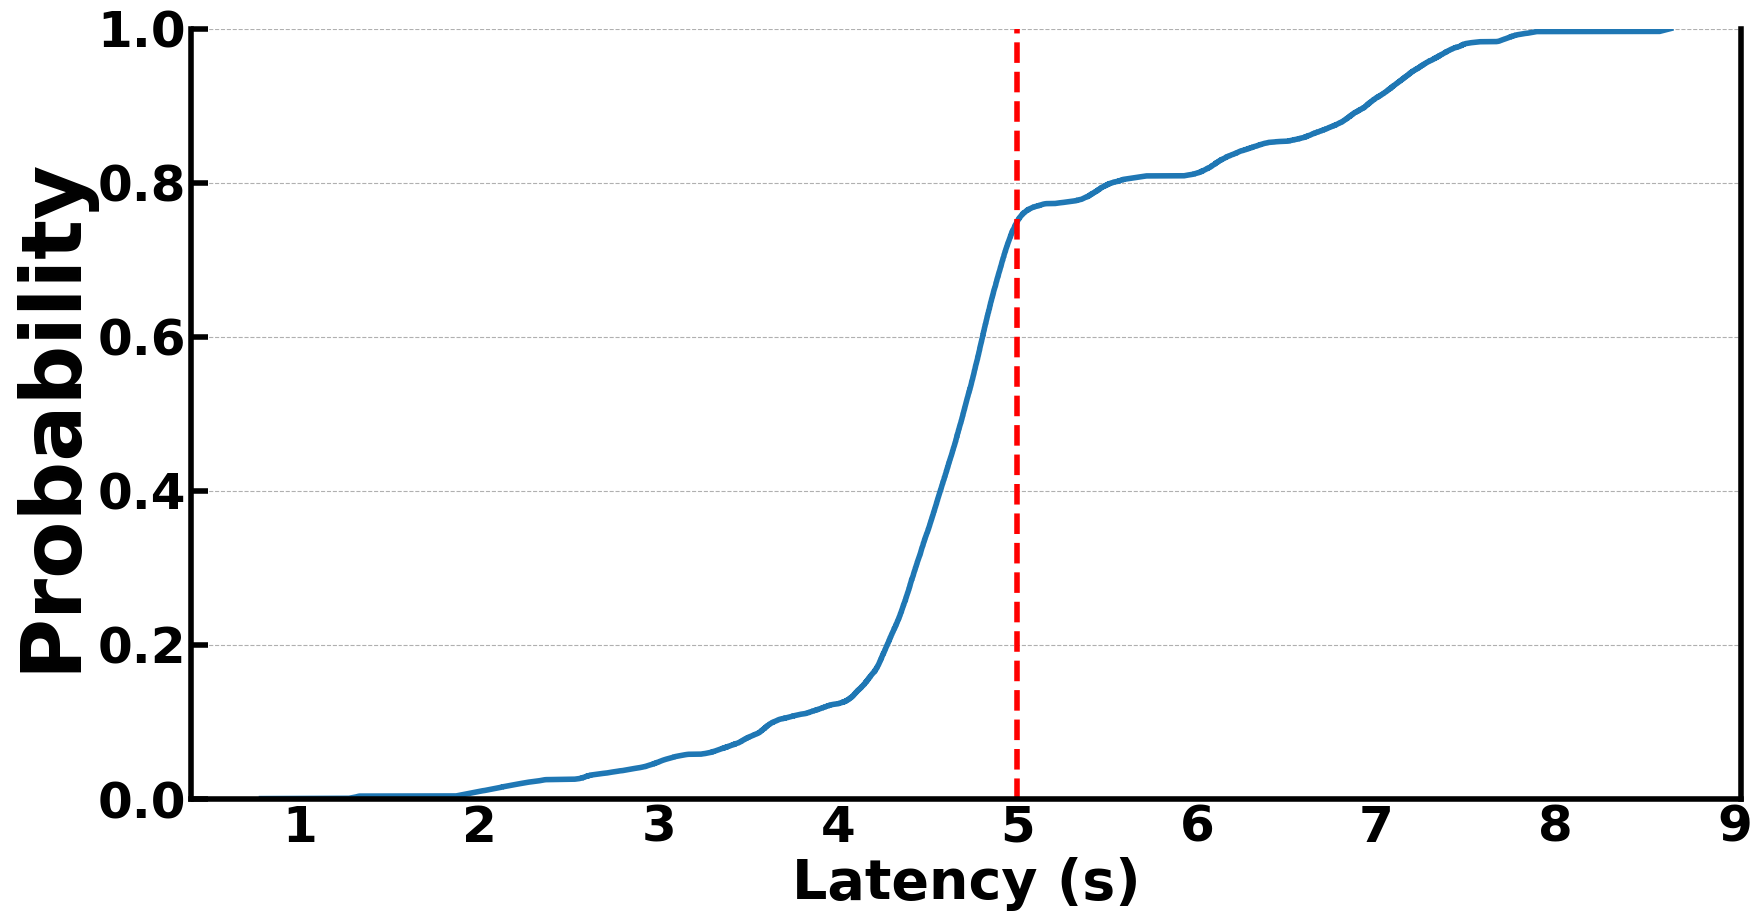

In [12]:
xlabelfontsize = 40
ylabelfontsize = 60
ticklabelfontsize = 36
legendfontsize = 26
lw = 4
markersize = 15


fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(np.sort(latency_us) / 1e6, np.linspace(0, 1, len(latency_us)), linewidth=lw)

ax.grid(axis='y', linestyle='--')
ax.set_axisbelow(True)

ax.axvline(x=5, c='r', linestyle='--', linewidth=lw)
ax.set_xlabel('Latency (s)', fontsize=xlabelfontsize, fontweight='bold')
ax.set_ylabel('Probability', fontsize=ylabelfontsize, fontweight='bold')
ax.set_ylim(0, 1)

ticklabels = ax.get_xticklabels() + ax.get_yticklabels()
[ticklabel.set_fontsize(ticklabelfontsize) for ticklabel in ticklabels]
[ticklabel.set_fontweight('bold') for ticklabel in ticklabels]

ax.spines['left'].set_linewidth(lw)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_linewidth(lw)
ax.spines['bottom'].set_linewidth(lw)

ax.tick_params('x', which='minor', direction='in', length=12, width=lw)
ax.tick_params('y', which='major', direction='in', length=12, width=lw)
ax.tick_params('x', which='major', direction='in', length=0,  width=lw)
ax.tick_params('y', which='minor', direction='in', length=0,  width=lw)

plt.show()

In [13]:
pack_start = 'scheduledTime'
# pack_end = 'mixedInferenceEndTime'
pack_end = 'reconstructEndTime'
full_start = 'scheduledTime'
full_end = 'fullInferenceEndTime'
assert np.all(df_pack[pack_end].values > 0) and np.all(df_pack[pack_start].values > 0)
assert np.all(df_pack[pack_end].values > df_pack[pack_start].values)

latency_us = np.hstack([(df_pack[pack_end] - df_pack[pack_start]).values, (df_full[full_end] - df_full[full_start]).values])

In [14]:
sum(latency_us > 2.5e6) / latency_us.shape[0]

0.03232364301687335

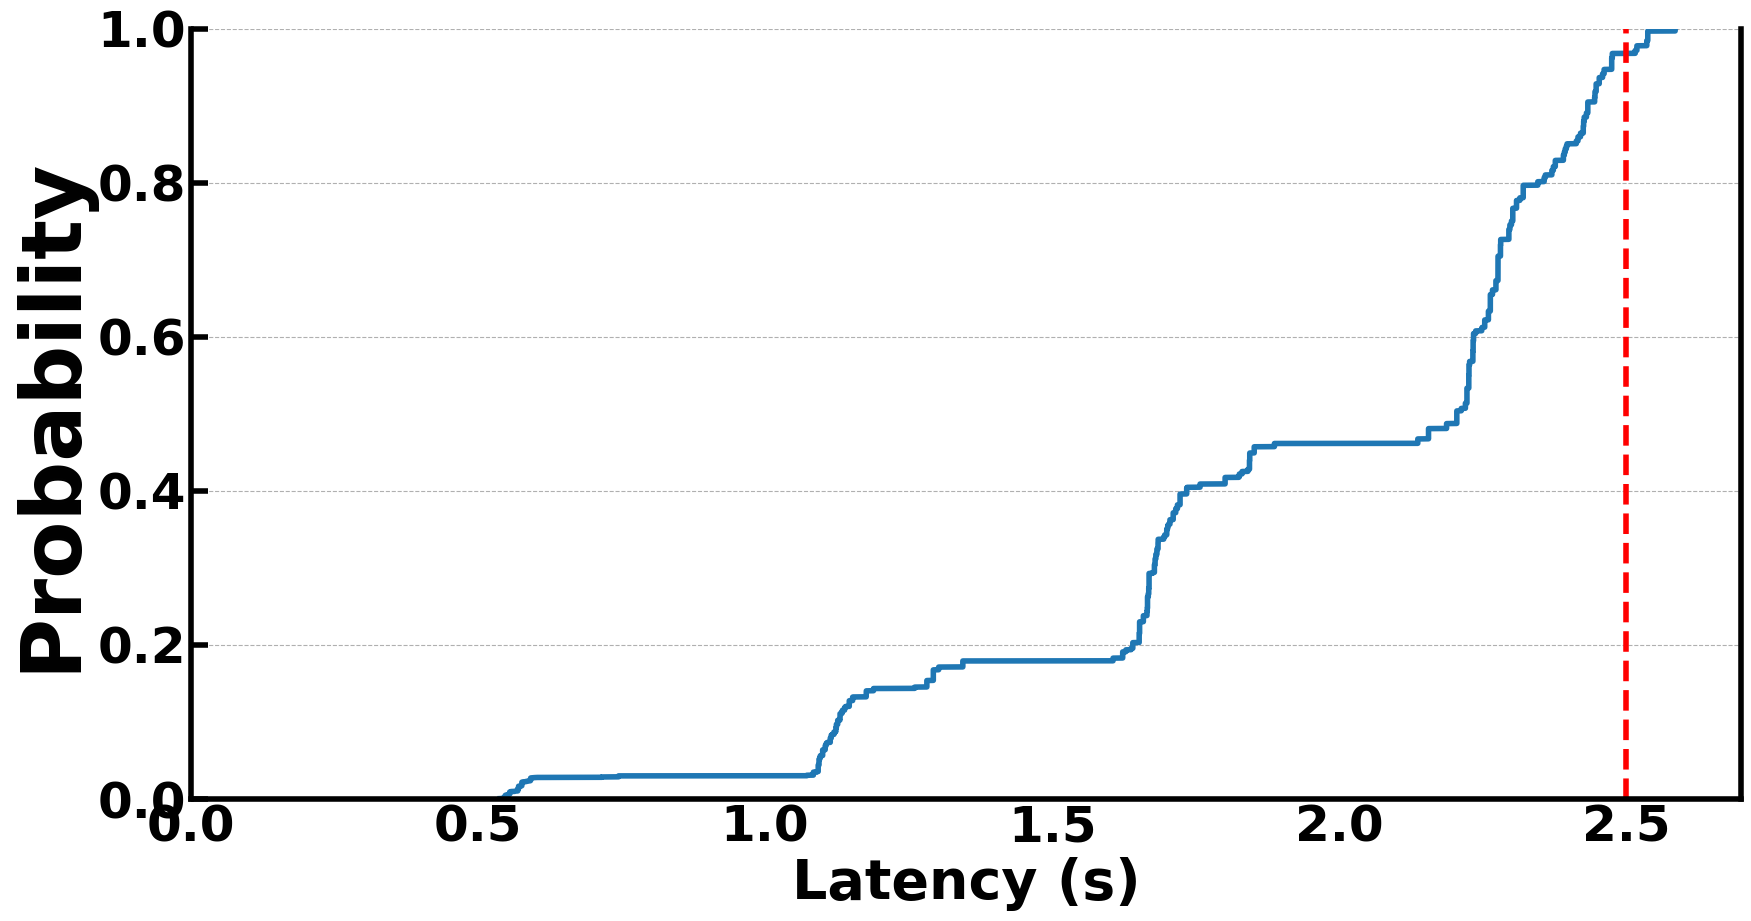

In [15]:
xlabelfontsize = 40
ylabelfontsize = 60
ticklabelfontsize = 36
legendfontsize = 26
lw = 4
markersize = 15


fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(np.sort(latency_us) / 1e6, np.linspace(0, 1, len(latency_us)), linewidth=lw)

ax.grid(axis='y', linestyle='--')
ax.set_axisbelow(True)

ax.axvline(x=2.5, c='r', linestyle='--', linewidth=lw)
ax.set_xlabel('Latency (s)', fontsize=xlabelfontsize, fontweight='bold')
ax.set_ylabel('Probability', fontsize=ylabelfontsize, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xlim(0, 2.7)

ticklabels = ax.get_xticklabels() + ax.get_yticklabels()
[ticklabel.set_fontsize(ticklabelfontsize) for ticklabel in ticklabels]
[ticklabel.set_fontweight('bold') for ticklabel in ticklabels]

ax.spines['left'].set_linewidth(lw)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_linewidth(lw)
ax.spines['bottom'].set_linewidth(lw)

ax.tick_params('x', which='minor', direction='in', length=12, width=lw)
ax.tick_params('y', which='major', direction='in', length=12, width=lw)
ax.tick_params('x', which='major', direction='in', length=0,  width=lw)
ax.tick_params('y', which='minor', direction='in', length=0,  width=lw)

plt.show()